<a href="https://colab.research.google.com/github/AdnanAnwarR/practice_DS/blob/main/Hands_on_Data_Cleaning_Day_12_Adnan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries installed successfully!")
print("=" * 80)

✓ All libraries installed successfully!


## Create Sample DataFrame

In [2]:
sample_data = {
    'student_id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'age': [20, 22, 21, 23, 20],
    'grade': ['A', 'B', 'A', 'C', 'B'],
    'score': [95, 82, 88, 75, 85]
}

df_sample = pd.DataFrame(sample_data)
df_sample

,student_id,name,age,grade,score
0,1,Alice,20,A,95
1,2,Bob,22,B,82
2,3,Charlie,21,A,88
3,4,David,23,C,75
4,5,Eve,20,B,85


In [3]:
# Check Data Characteristic
print("\n1. head() - First 3 rows:")
print(df_sample.head(3))

print("\n2. tail() - Last 5 rows:")
print(df_sample.tail(10))

print("\n3. info() - Data types and info:")
df_sample.info()

print("\n4. describe() - Statistical summary:")
print(df_sample.describe())

print("\n5. shape - Dimensions:")
print(f"   Shape: {df_sample.shape} (rows, columns)")

print("\n6. columns - Column names:")
print(f"   Columns: {list(df_sample.columns)}")


1. head() - First 3 rows:
   student_id     name  age grade  score
0           1    Alice   20     A     95
1           2      Bob   22     B     82
2           3  Charlie   21     A     88

2. tail() - Last 5 rows:
   student_id     name  age grade  score
0           1    Alice   20     A     95
1           2      Bob   22     B     82
2           3  Charlie   21     A     88
3           4    David   23     C     75
4           5      Eve   20     B     85

3. info() - Data types and info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  5 non-null      int64 
 1   name        5 non-null      object
 2   age         5 non-null      int64 
 3   grade       5 non-null      object
 4   score       5 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 332.0+ bytes

4. describe() - Statistical summary:
       student_id       age   

## Data Types

In [4]:
data = pd.read_csv('data_cleaning.csv')
data

,height_cm,weight_kg,temperature,salary,age,children_count,years_experience,gender,city,department,work_type,education,job_level,satisfaction,hire_date,phone
0,165.0,46.4,37.0,3620181.0,58,0,16,Female,Medan,HR,Office,S1,Senior,Medium,2020-01-01,564071
1,188.0,73.6,36.1,9376256.0,47,0,15,Male,Bandung,IT,Remote,SMP,Mid,Very High,2020-01-04,898798296
2,179.3,59.1,36.2,9487621.0,34,0,14,Male,Surabaya,IT,Hybrid,SMA,Senior,Medium,2020-01-07,820563214
3,173.9,67.9,37.3,10649159.0,37,4,22,Male,Medan,IT,Remote,D3,Mid,High,2020-01-10,834374842
4,156.2,85.8,36.9,11713096.0,42,2,14,Female,Surabaya,IT,Remote,SMA,Senior,Low,2020-01-13,891252249
5,156.2,56.2,36.0,14710225.0,39,0,4,Male,Jakarta,HR,Remote,SMA,Senior,High,2020-01-16,897384552
6,152.3,63.5,36.2,9195604.0,30,2,20,Male,Bandung,HR,Remote,D3,Senior,Low,2020-01-19,838172140
7,184.6,79.0,37.0,6875478.0,36,3,13,Male,Jakarta,Marketing,Office,SMA,Lead,Very High,2020-01-22,868701337
8,174.0,55.3,36.0,12542234.0,53,1,1,Female,Jakarta,Finance,Office,D3,Lead,High,2020-01-25,845119150
9,178.3,48.5,36.2,6249987.0,29,3,10,Male,Jakarta,HR,Remote,SMP,Junior,Medium,2020-01-28,865471391


In [5]:
## Cek tipe data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   height_cm         100 non-null    float64
 1   weight_kg         100 non-null    float64
 2   temperature       100 non-null    float64
 3   salary            100 non-null    float64
 4   age               100 non-null    int64  
 5   children_count    100 non-null    int64  
 6   years_experience  100 non-null    int64  
 7   gender            100 non-null    object 
 8   city              100 non-null    object 
 9   department        100 non-null    object 
 10  work_type         100 non-null    object 
 11  education         100 non-null    object 
 12  job_level         100 non-null    object 
 13  satisfaction      100 non-null    object 
 14  hire_date         100 non-null    object 
 15  phone             100 non-null    int64  
dtypes: float64(4), int64(4), object(8)
memory usa

In [6]:
data.isna().sum()

,0
height_cm,0
weight_kg,0
temperature,0
salary,0
age,0
children_count,0
years_experience,0
gender,0
city,0
department,0


## Flow Data Cleaning

In [7]:
## Load data
df_messy = pd.read_csv('data_employee.csv')
df_messy

,employee_id,name,age,gender,department,education,years_experience,salary,performance_score,satisfaction_level,projects_completed,overtime_hours
0,1,Employee_1,58.0,female,IT,S2,7,9.991337e+06,74.6,High,31,46.0
1,2,Employee_2,48.0,Male,IT,D3,9,1.621924e+07,79.5,Very High,45,7.6
2,3,Employee_3,34.0,Male,IT,S1,8,1.116629e+07,94.0,High,42,7.8
3,4,Employee_4,27.0,Male,IT,S2,17,1.974986e+07,63.5,Low,15,0.2
4,5,Employee_5,40.0,M,Sales,SMP,26,9.404562e+06,92.2,High,3,96.8
...,...,...,...,...,...,...,...,...,...,...,...,...
150,74,Employee_74,45.0,M,Finance,S1,20,5.662623e+07,88.6,High,10,27.2
151,19,Employee_19,NaN,Female,HR,SMP,16,9.310072e+07,92.8,Medium,47,72.4
152,119,Employee_119,46.0,female,Finance,S2,8,3.518027e+06,93.1,High,48,26.0
153,79,Employee_79,44.0,M,IT,SMP,2,NaN,83.1,Medium,35,73.2


In [8]:
# Check for duplicates
print(f"\n Number of duplicate rows: {df_messy.duplicated().sum()}")

# Show duplicate rows
print("\nDuplicate Rows:")
duplicates = df_messy[df_messy.duplicated(keep=False)]
print(duplicates.sort_values('employee_id'))

# Check duplicates on specific columns
print("\n Duplicates based on employee_id:")
dup_by_id = df_messy[df_messy.duplicated(subset=['employee_id'], keep=False)]
print(f"Count: {len(dup_by_id)}")


 Number of duplicate rows: 2

Duplicate Rows:
     employee_id          name   age  gender department education  \
76            77   Employee_77  34.0  Female      Sales       SMP   
154           77   Employee_77  34.0  Female      Sales       SMP   
118          119  Employee_119  46.0  female    Finance        S2   
152          119  Employee_119  46.0  female    Finance        S2   

     years_experience     salary  performance_score satisfaction_level  \
76                  4  6061144.0               81.6             Medium   
154                 4  6061144.0               81.6             Medium   
118                 8  3518027.0               93.1               High   
152                 8  3518027.0               93.1               High   

     projects_completed  overtime_hours  
76                   20            33.6  
154                  20            33.6  
118                  48            26.0  
152                  48            26.0  

 Duplicates based on empl

In [9]:
# Remove duplicates (keep first occurrence)
df_clean = df_messy.drop_duplicates(keep='first')

print(f" After removing duplicates: {len(df_clean)} rows")
print(f" Removed {len(df_messy) - len(df_clean)} duplicate rows")

# Verify no more duplicates
print(f"\n✓ Verification - Remaining duplicates: {df_clean.duplicated().sum()}")

 After removing duplicates: 153 rows
 Removed 2 duplicate rows

✓ Verification - Remaining duplicates: 0


## Handling Missing Values

In [10]:
# --- Identify Missing Values ---
print("\n--- Identifying Missing Values ---")

# Count missing values
print("\n📊 Missing Values Count:")
missing_count = df_clean.isnull().sum()
print(missing_count[missing_count > 0])

# Percentage of missing values
print("\n📊 Missing Values Percentage:")
missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))




--- Identifying Missing Values ---

📊 Missing Values Count:
age           15
department     8
education     12
salary        10
dtype: int64

📊 Missing Values Percentage:
            Missing Count  Missing %
age                    15       9.80
education              12       7.84
salary                 10       6.54
department              8       5.23


In [11]:
# --- Check Unique Values ---
print("\n--- Checking Unique Values in Each Column ---")

print("\n📊 Unique Values per Column:")
for col in df_clean.columns:
    unique_count = df_clean[col].nunique()
    print(f"   {col}: {unique_count} unique values")
    if df_clean[col].dtype == 'object' and unique_count < 20:
        print(f"      Values: {df_clean[col].unique()[:10]}")


--- Checking Unique Values in Each Column ---

📊 Unique Values per Column:
   employee_id: 150 unique values
   name: 150 unique values
   age: 40 unique values
   gender: 7 unique values
      Values: ['female' 'Male' 'M' 'F' 'male' 'Female' 'Unknown']
   department: 5 unique values
      Values: ['IT' 'Sales' 'HR' nan 'Finance' 'Marketing']
   education: 5 unique values
      Values: ['S2' 'D3' 'S1' 'SMP' nan 'SMA']
   years_experience: 30 unique values
   salary: 143 unique values
   performance_score: 127 unique values
   satisfaction_level: 4 unique values
      Values: ['High' 'Very High' 'Low' 'Medium']
   projects_completed: 47 unique values
   overtime_hours: 144 unique values


In [12]:
df_clean['department'].nunique()

5

In [13]:
# --- Missing Value Decision Rules ---
print("\n--- Missing Value Handling Strategy ---")

print("\n📋 DECISION RULES:")
print("=" * 60)
print("1. If missing > 20%: DROP the column")
print("2. If missing ≤ 20%:")
print("   - Numerical column: Fill with MEDIAN (from train data)")
print("   - Categorical column: Fill with MODE (from train data)")
print("=" * 60)

# Apply decision rules
threshold = 20  # 20% threshold

for col in df_clean.columns:
    missing_pct = (df_clean[col].isnull().sum() / len(df_clean)) * 100

    if missing_pct > threshold:
        print(f"\n🔴 DROP {col}: {missing_pct:.2f}% missing (> {threshold}%)")
    elif missing_pct > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            print(f"\n🟡 FILL {col}: {missing_pct:.2f}% missing - Use MEDIAN")
        else:
            print(f"\n🟡 FILL {col}: {missing_pct:.2f}% missing - Use MODE")



--- Missing Value Handling Strategy ---

📋 DECISION RULES:
1. If missing > 20%: DROP the column
2. If missing ≤ 20%:
   - Numerical column: Fill with MEDIAN (from train data)
   - Categorical column: Fill with MODE (from train data)

🟡 FILL age: 9.80% missing - Use MEDIAN

🟡 FILL department: 5.23% missing - Use MODE

🟡 FILL education: 7.84% missing - Use MODE

🟡 FILL salary: 6.54% missing - Use MEDIAN


In [14]:
# --- Handle Numerical Missing Values ---
print("\n--- Handling Numerical Missing Values ---")

# Fill numerical columns with median
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

print("\n📊 Numerical columns:")
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)
        print(f"   ✓ {col}: Filled {df_clean[col].isnull().sum()} missing with median = {median_value:.2f}")



--- Handling Numerical Missing Values ---

📊 Numerical columns:
   ✓ age: Filled 0 missing with median = 42.00
   ✓ salary: Filled 0 missing with median = 12085200.00


In [15]:
# --- Handle Categorical Missing Values ---
print("\n--- Handling Categorical Missing Values ---")

# Fill categorical columns with mode
categorical_cols = df_clean.select_dtypes(include=['object']).columns

print("\n📊 Categorical columns:")
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"   ✓ {col}: Filled missing with mode = '{mode_value}'")

# Verify no more missing values
print("\n✓ Verification - Remaining missing values:")
print(df_clean.isnull().sum().sum())


--- Handling Categorical Missing Values ---

📊 Categorical columns:
   ✓ department: Filled missing with mode = 'IT'
   ✓ education: Filled missing with mode = 'SMP'

✓ Verification - Remaining missing values:
0


In [16]:
# --- Handle Inconsistent Values ---
print("\n--- Handling Inconsistent Categorical Values ---")

# Standardize gender column
print("\n📊 Standardizing 'gender' column:")
print(f"   Before: {df_clean['gender'].unique()}")

# Map all variations to standard values
gender_mapping = {
    'Male': 'Male',
    'M': 'Male',
    'male': 'Male',
    'Female': 'Female',
    'F': 'Female',
    'female': 'Female',
    'Unknown': 'Unknown'
}

df_clean['gender'] = df_clean['gender'].map(gender_mapping)
print(f"   After: {df_clean['gender'].unique()}")
print(f"   Value counts:\n{df_clean['gender'].value_counts()}")

# Handle 'Unknown' values in gender
mode_gender = df_clean[df_clean['gender'] != 'Unknown']['gender'].mode()[0]
df_clean['gender'] = df_clean['gender'].replace('Unknown', mode_gender)
print(f"\n   ✓ Replaced 'Unknown' with mode: '{mode_gender}'")


--- Handling Inconsistent Categorical Values ---

📊 Standardizing 'gender' column:
   Before: ['female' 'Male' 'M' 'F' 'male' 'Female' 'Unknown']
   After: ['Female' 'Male' 'Unknown']
   Value counts:
gender
Male       81
Female     67
Unknown     5
Name: count, dtype: int64

   ✓ Replaced 'Unknown' with mode: 'Male'


## Handling Outliers


--- Visualizing Outliers ---


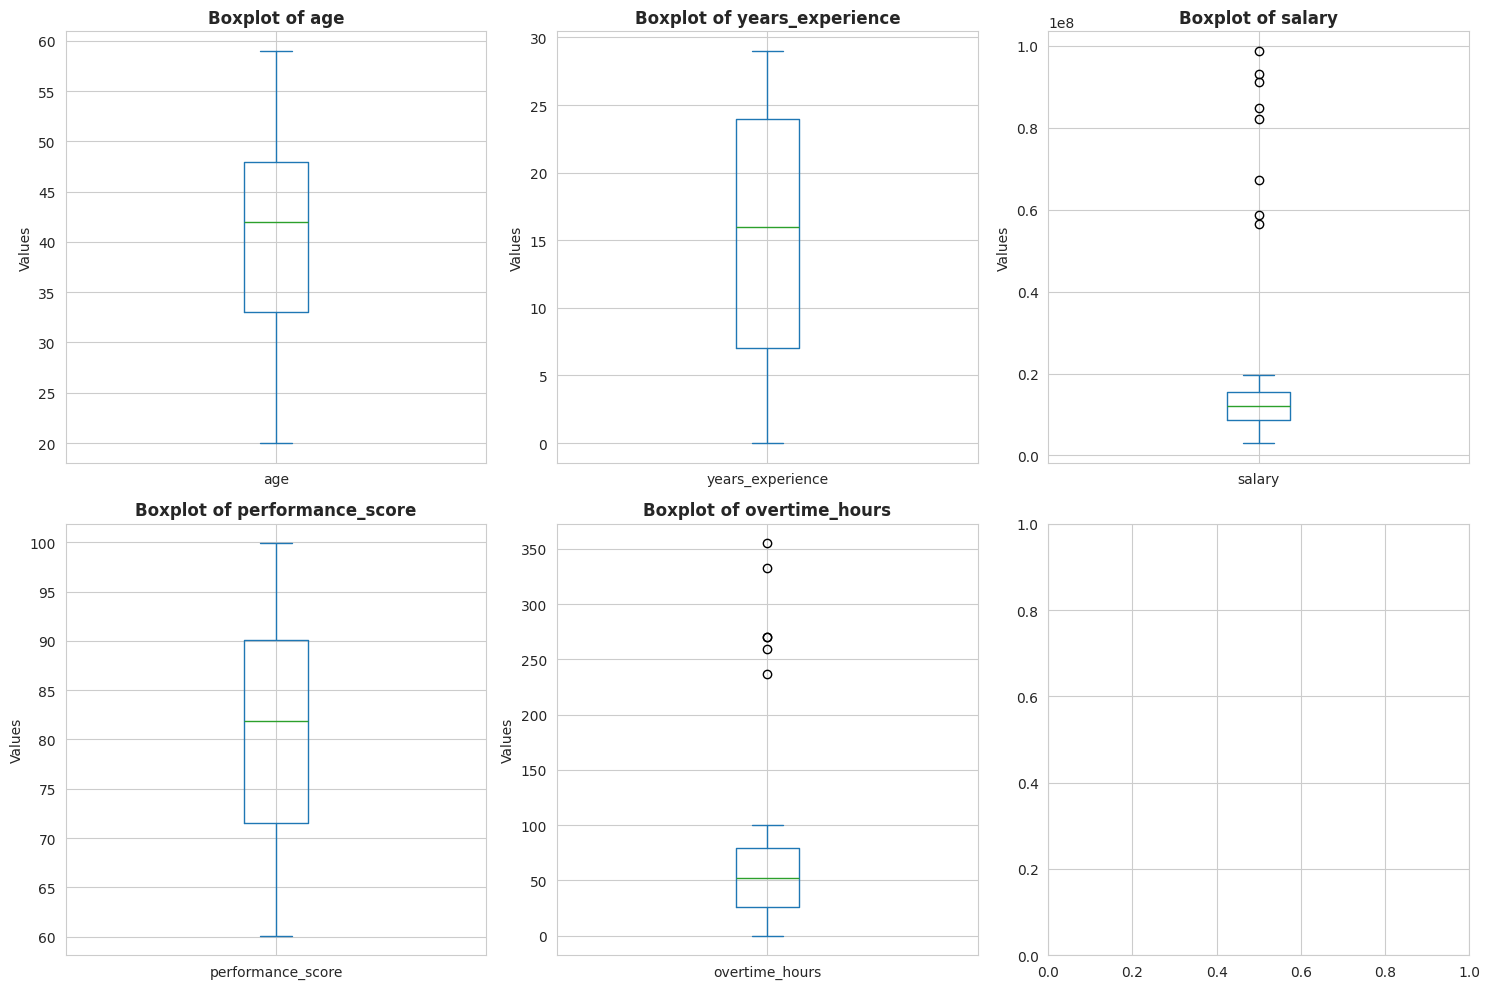

In [17]:
# --- Visualize Outliers ---
print("\n--- Visualizing Outliers ---")

# Create boxplots for numerical columns
numerical_cols_for_outliers = ['age', 'years_experience', 'salary',
                                'performance_score', 'overtime_hours']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols_for_outliers):
    df_clean[col].plot(kind='box', ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[idx].set_ylabel('Values')

plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


In [18]:
# --- IQR Method Theory ---
print("\n--- IQR (Inter Quartile Range) Method ---")

print("\n📚 IQR METHOD THEORY:")
print("=" * 60)
print("1. Q1 (25th percentile): 25% of data below this value")
print("2. Q3 (75th percentile): 75% of data below this value")
print("3. IQR = Q3 - Q1")
print("4. Lower Bound = Q1 - 1.5 × IQR")
print("5. Upper Bound = Q3 + 1.5 × IQR")
print("6. Outliers: Values < Lower Bound OR Values > Upper Bound")
print("=" * 60)

# Demonstrate IQR calculation
print("\n📊 IQR Calculation Example for 'salary':")
Q1 = df_clean['salary'].quantile(0.25)
Q3 = df_clean['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"   Q1 (25%): Rp {Q1:,.0f}")
print(f"   Q3 (75%): Rp {Q3:,.0f}")
print(f"   IQR: Rp {IQR:,.0f}")
print(f"   Lower Bound: Rp {lower_bound:,.0f}")
print(f"   Upper Bound: Rp {upper_bound:,.0f}")

# Count outliers
outliers_salary = df_clean[(df_clean['salary'] < lower_bound) |
                           (df_clean['salary'] > upper_bound)]
print(f"\n   🔴 Outliers found: {len(outliers_salary)} rows")
print(f"   Outlier percentage: {len(outliers_salary)/len(df_clean)*100:.2f}%")


--- IQR (Inter Quartile Range) Method ---

📚 IQR METHOD THEORY:
1. Q1 (25th percentile): 25% of data below this value
2. Q3 (75th percentile): 75% of data below this value
3. IQR = Q3 - Q1
4. Lower Bound = Q1 - 1.5 × IQR
5. Upper Bound = Q3 + 1.5 × IQR
6. Outliers: Values < Lower Bound OR Values > Upper Bound

📊 IQR Calculation Example for 'salary':
   Q1 (25%): Rp 8,736,596
   Q3 (75%): Rp 15,535,889
   IQR: Rp 6,799,293
   Lower Bound: Rp -1,462,344
   Upper Bound: Rp 25,734,828

   🔴 Outliers found: 8 rows
   Outlier percentage: 5.23%


In [19]:
no_outliers_salary = df_clean[(df_clean['salary'] > lower_bound) &
                           (df_clean['salary'] < upper_bound)]
len(no_outliers_salary)

145

In [20]:
## overtime outliers (exercise)

## Category Encoding

In [21]:
# --- Identify Categorical Columns ---
print("\n--- Identifying Categorical Columns ---")

categorical_columns = df_clean.select_dtypes(include=['object']).columns
print(f"\n📊 Categorical Columns: {list(categorical_columns)}")

for col in categorical_columns:
    print(f"\n{col}:")
    print(f"   Unique values: {df_clean[col].nunique()}")
    print(f"   Values: {df_clean[col].unique()}")
    print(f"   Type: ", end="")

    # Determine type
    if col in ['education', 'satisfaction_level']:
        print("ORDINAL (has order)")
    elif df_clean[col].nunique() > 20:
        print("HIGH CARDINALITY")
    else:
        print("NOMINAL (no order)")


--- Identifying Categorical Columns ---

📊 Categorical Columns: ['name', 'gender', 'department', 'education', 'satisfaction_level']

name:
   Unique values: 150
   Values: ['Employee_1' 'Employee_2' 'Employee_3' 'Employee_4' 'Employee_5'
 'Employee_6' 'Employee_7' 'Employee_8' 'Employee_9' 'Employee_10'
 'Employee_11' 'Employee_12' 'Employee_13' 'Employee_14' 'Employee_15'
 'Employee_16' 'Employee_17' 'Employee_18' 'Employee_19' 'Employee_20'
 'Employee_21' 'Employee_22' 'Employee_23' 'Employee_24' 'Employee_25'
 'Employee_26' 'Employee_27' 'Employee_28' 'Employee_29' 'Employee_30'
 'Employee_31' 'Employee_32' 'Employee_33' 'Employee_34' 'Employee_35'
 'Employee_36' 'Employee_37' 'Employee_38' 'Employee_39' 'Employee_40'
 'Employee_41' 'Employee_42' 'Employee_43' 'Employee_44' 'Employee_45'
 'Employee_46' 'Employee_47' 'Employee_48' 'Employee_49' 'Employee_50'
 'Employee_51' 'Employee_52' 'Employee_53' 'Employee_54' 'Employee_55'
 'Employee_56' 'Employee_57' 'Employee_58' 'Employee_59

In [22]:
# --- Label Encoding (for Ordinal Data) ---
print("\n--- Label Encoding for Ordinal Data ---")

print("\n📊 Label Encoding - Education:")
print("   SMP → 1, SMA → 2, D3 → 3, S1 → 4, S2 → 5")

# Create a copy for encoding
df_encoded = df_clean.copy()

# Define ordinal mappings
education_mapping = {
    'SMP': 1,
    'SMA': 2,
    'D3': 3,
    'S1': 4,
    'S2': 5
}

satisfaction_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4
}

# Apply label encoding
df_encoded['education_encoded'] = df_encoded['education'].map(education_mapping)
df_encoded['satisfaction_encoded'] = df_encoded['satisfaction_level'].map(satisfaction_mapping)

print("\nEducation Encoding Result:")
print(df_encoded[['education', 'education_encoded']].drop_duplicates().sort_values('education_encoded'))

print("\nSatisfaction Encoding Result:")
print(df_encoded[['satisfaction_level', 'satisfaction_encoded']].drop_duplicates().sort_values('satisfaction_encoded'))

# Alternative: Using LabelEncoder from sklearn
print("\nUsing sklearn LabelEncoder:")
le = LabelEncoder()
df_encoded['gender_encoded'] = le.fit_transform(df_encoded['gender'])

print("\n   Gender Encoding:")
for i, label in enumerate(le.classes_):
    print(f"   {label} → {i}")


--- Label Encoding for Ordinal Data ---

📊 Label Encoding - Education:
   SMP → 1, SMA → 2, D3 → 3, S1 → 4, S2 → 5

Education Encoding Result:
  education  education_encoded
4       SMP                  1
9       SMA                  2
1        D3                  3
2        S1                  4
0        S2                  5

Satisfaction Encoding Result:
  satisfaction_level  satisfaction_encoded
3                Low                     1
8             Medium                     2
0               High                     3
1          Very High                     4

Using sklearn LabelEncoder:

   Gender Encoding:
   Female → 0
   Male → 1


In [23]:
# --- One Hot Encoding (for Nominal Data) ---
print("\n--- One Hot Encoding for Nominal Data ---")

print("\n📚 ONE HOT ENCODING CONCEPT:")
print("   Creates binary columns for each category")
print("   Example: department")
print("   Original: ['IT', 'Finance', 'HR']")
print("   Becomes: dept_IT, dept_Finance, dept_HR")
print("   IT      → [1, 0, 0]")
print("   Finance → [0, 1, 0]")
print("   HR      → [0, 0, 1]")

# Apply one-hot encoding
print("\n📊 Applying One Hot Encoding to 'department':")
print(f"   Original shape: {df_encoded.shape}")

# Method 1: Using pd.get_dummies
df_encoded = pd.get_dummies(df_encoded, columns=['department'], prefix='dept')

print(f"   After OHE shape: {df_encoded.shape}")
print(f"\n   New columns created:")
dept_columns = [col for col in df_encoded.columns if col.startswith('dept_')]
print(f"   {dept_columns}")

# Show example
print("\n📊 One Hot Encoding Example (first 5 rows):")
print(df_encoded[['name'] + dept_columns].head())

# Apply one-hot encoding to gender
df_encoded = pd.get_dummies(df_encoded, columns=['gender'], prefix='gender', drop_first=True)
print("\n📊 Gender One Hot Encoding (drop_first=True):")
gender_columns = [col for col in df_encoded.columns if col.startswith('gender_')]
print(f"   Columns: {gender_columns}")
print(f"   Note: drop_first=True removes one category to avoid multicollinearity")


--- One Hot Encoding for Nominal Data ---

📚 ONE HOT ENCODING CONCEPT:
   Creates binary columns for each category
   Example: department
   Original: ['IT', 'Finance', 'HR']
   Becomes: dept_IT, dept_Finance, dept_HR
   IT      → [1, 0, 0]
   Finance → [0, 1, 0]
   HR      → [0, 0, 1]

📊 Applying One Hot Encoding to 'department':
   Original shape: (153, 15)
   After OHE shape: (153, 19)

   New columns created:
   ['dept_Finance', 'dept_HR', 'dept_IT', 'dept_Marketing', 'dept_Sales']

📊 One Hot Encoding Example (first 5 rows):
         name  dept_Finance  dept_HR  dept_IT  dept_Marketing  dept_Sales
0  Employee_1         False    False     True           False       False
1  Employee_2         False    False     True           False       False
2  Employee_3         False    False     True           False       False
3  Employee_4         False    False     True           False       False
4  Employee_5         False    False    False           False        True

📊 Gender One Hot En

In [24]:
# --- Mean Encoding (Target Encoding) ---
print("\n--- Mean Encoding for High Cardinality ---")

print("\n📚 MEAN ENCODING CONCEPT:")
print("   Replace category with mean of target variable")
print("   Good for high cardinality features")
print("   Example: Replace department with avg performance score")

# Calculate mean performance by department (using original df_clean)
dept_mean_performance = df_clean.groupby('department')['performance_score'].mean()

print("\n📊 Mean Performance Score by Department:")
print(dept_mean_performance.round(2))

# Create mean encoding
df_mean_encoded = df_clean.copy()
df_mean_encoded['dept_mean_encoded'] = df_mean_encoded['department'].map(dept_mean_performance)

print("\n📊 Mean Encoding Result:")
print(df_mean_encoded[['department', 'dept_mean_encoded', 'performance_score']].head(10))


--- Mean Encoding for High Cardinality ---

📚 MEAN ENCODING CONCEPT:
   Replace category with mean of target variable
   Good for high cardinality features
   Example: Replace department with avg performance score

📊 Mean Performance Score by Department:
department
Finance      80.07
HR           79.20
IT           81.89
Marketing    83.12
Sales        78.70
Name: performance_score, dtype: float64

📊 Mean Encoding Result:
  department  dept_mean_encoded  performance_score
0         IT          81.894828               74.6
1         IT          81.894828               79.5
2         IT          81.894828               94.0
3         IT          81.894828               63.5
4      Sales          78.700000               92.2
5         HR          79.200000               62.2
6         IT          81.894828               93.7
7         HR          79.200000               62.1
8         HR          79.200000               60.7
9    Finance          80.066667               87.9


In [25]:
# --- Comparison of Encoding Methods ---
print("\n--- Comparing Encoding Methods ---")

comparison_df = pd.DataFrame({
    'Original': df_clean['department'].head(10),
    'Label_Encoded': LabelEncoder().fit_transform(df_clean['department'].head(10)),
    'Mean_Encoded': df_clean['department'].head(10).map(dept_mean_performance).round(2)
})

print("\n📊 Encoding Methods Comparison:")
print(comparison_df)


--- Comparing Encoding Methods ---

📊 Encoding Methods Comparison:
  Original  Label_Encoded  Mean_Encoded
0       IT              2         81.89
1       IT              2         81.89
2       IT              2         81.89
3       IT              2         81.89
4    Sales              3         78.70
5       HR              1         79.20
6       IT              2         81.89
7       HR              1         79.20
8       HR              1         79.20
9  Finance              0         80.07
